# Calculate OHC in surface mixed layer in eastern and western Beaufort

In [93]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:35691")
client

<Client: 'tcp://127.0.0.1:35691' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

In [7]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### Select boxes in eastern and western Beaufort Sea

In [36]:
salt_beaufort = SALT_zarr_day.SALT.isel(i=slice(450,700),j=slice(110,390)).sel(k=slice(0,16))
temp_beaufort = THETA_zarr_day.THETA.isel(i=slice(450,700),j=slice(110,390)).sel(k=slice(0,16))
sic_beaufort = SI_zarr_day.SIarea.isel(i=slice(450,700),j=slice(110,390))

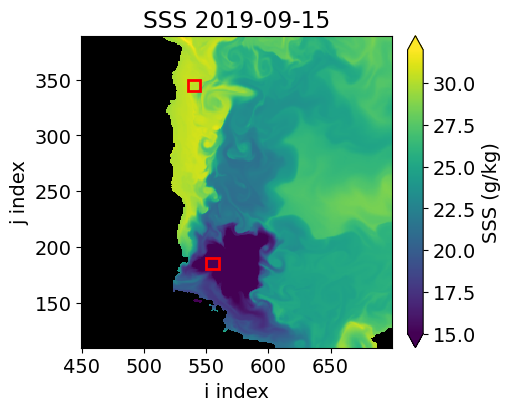

In [59]:
import matplotlib.patches as patches

plt.rcParams['font.size'] = 14
fig = plt.figure(figsize=(5,4), constrained_layout=True)
ax1 = fig.add_subplot(1,1,1)

# Plot the data
salt_beaufort.sel(time='2019-09-15').isel(k=0).plot(ax=ax1, vmin=15, vmax=32, cmap='viridis',cbar_kwargs={'label': 'SSS (g/kg)'})

ax1.set_facecolor('k')

# plot two boxes
box1 = patches.Rectangle((550, 180), 10, 10, linewidth=2, edgecolor='red', facecolor='none')
box2 = patches.Rectangle((535, 340), 10, 10, linewidth=2, edgecolor='red', facecolor='none')

# Add boxes to the plot
ax1.add_patch(box1)
ax1.add_patch(box2)

ax1.set_ylabel("j index")
ax1.set_xlabel("i index")
ax1.set_title("SSS 2019-09-15")

plt.show()

### Subset east and west boxes

In [100]:
# eastern beaufort
salt_east = SALT_zarr_day.SALT.isel(i=slice(550,560),j=slice(180,190)).sel(k=slice(0,16))
temp_east = THETA_zarr_day.THETA.isel(i=slice(550,560),j=slice(180,190)).sel(k=slice(0,16))
sic_east = SI_zarr_day.SIarea.isel(i=slice(550,560),j=slice(180,190))
grid_east = HH_grid.isel(i=slice(550,560),j=slice(180,190)).sel(k=slice(0,16))

In [102]:
# western beaufort
salt_west = SALT_zarr_day.SALT.isel(i=slice(535,545),j=slice(340,350)).sel(k=slice(0,16))
temp_west = THETA_zarr_day.THETA.isel(i=slice(535,545),j=slice(340,350)).sel(k=slice(0,16))
sic_west = SI_zarr_day.SIarea.isel(i=slice(535,545),j=slice(340,350))
grid_west = HH_grid.isel(i=slice(550,560),j=slice(180,190)).sel(k=slice(0,16))

### Calculate potential density

In [84]:
def compute_potential_density(SALT_day, THETA_day, ref_lat=70):
    """
    Compute potential density anomaly referenced to 0 dbar.

    Args:
    - SALT_day: DataArray containing salinity (SALT), longitude (XC), and latitude (YC).
    - THETA_day: DataArray containing potential temperature (THETA).
    - ref_lat: Reference latitude for pressure calculation (default is 70°N).

    Returns:
    - sigma0: Potential density anomaly (kg/m³ - 1000).
    """
    # Convert depth (m) to pressure (dbar)
    p = gsw.p_from_z(SALT_day.Z, ref_lat)  # Depth is negative

    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(SALT_day, p, SALT_day.XC, SALT_day.YC)

    # Convert Potential Temperature to Conservative Temperature
    CT = gsw.conversions.CT_from_pt(SA, THETA_day)

    # Calculate potential density anomaly referenced to 0 dbar
    sigma0 = gsw.sigma0(SA, CT)

    # Add metadata
    sigma0.name = 'potential_density'
    sigma0.attrs['long_name'] = 'potential_density'

    return sigma0 + 1000

In [94]:
sigma_east = compute_potential_density(salt_east, temp_east, ref_lat=70)

In [95]:
sigma_west = compute_potential_density(salt_west, temp_west, ref_lat=70)

### Calculate OHC in ML

In [89]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
    - salinity (array): salinity (PSU)
    - temperature (array): temperature (°C)
    - depth (array): depth values (m, negative downward)
    - lon (float): longitude for SA calculation
    - lat (float): latitude for pressure calculation
    
    Args:
    - cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [129]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) for a time series of a profile at k=90.
    
    Args:
    - sigma0_array (xr.DataArray): Potential density dataset with dimensions (time, k).
    - density_threshold (float): Density increase threshold to define the MLD (default = 0.03 kg/m^3).
    
    Returns:
    - xr.DataArray: MLD time series corresponding to depth where density exceeds threshold.
    """
    
    # Select surface density
    rho_Z0 = sigma0_array.isel(k=0)
    
    # Compute threshold density
    threshold = (rho_Z0 + density_threshold)
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_array - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    
    # Extract the corresponding depth value for MLD
    MLD_array = sigma0_array.isel(k=threshold_idx.compute()).Z
    
    return MLD_array, threshold_idx

In [130]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # Given array of indices
    indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= indices
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

#### Calculate MLD

In [114]:
# calculate mld and the index of the mld along k coord for EASTERN beaufort
start = time.time()
mld_pt_east, threshold_idx_east = calculate_mld(sigma_east.sel(time=slice('2019','2020')), density_threshold=0.03)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 31.0 seconds


In [115]:
# calculate mld and the index of the mld along k coord for WESTERN beaufort
start = time.time()
mld_pt_west, threshold_idx_west = calculate_mld(sigma_west.sel(time=slice('2019','2020')), density_threshold=0.03)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 34.0 seconds


Time taken: 1.0 seconds


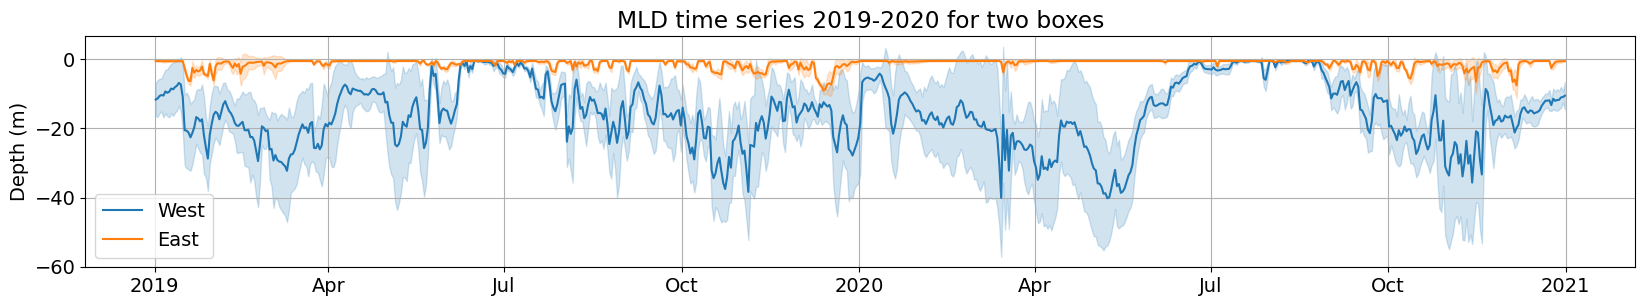

In [117]:
# Create a figure with 2 lines, one for each box
start = time.time()
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(nrows=1, figsize=(20, 3), sharex=True)

# Compute mean and standard deviation
mean_west = mld_pt_west.mean(dim=['j', 'i'])
std_west = mld_pt_west.std(dim=['j', 'i'])
mean_east = mld_pt_east.mean(dim=['j', 'i'])
std_east = mld_pt_east.std(dim=['j', 'i'])

# Plot mean lines
mean_west.plot(ax=ax, color='tab:blue', label='West')
mean_east.plot(ax=ax, color='tab:orange', label='East')

# Add shaded region for standard deviation
ax.fill_between(mean_west['time'], mean_west - std_west, mean_west + std_west, color='tab:blue', alpha=0.2)
ax.fill_between(mean_east['time'], mean_east - std_east, mean_east + std_east, color='tab:orange', alpha=0.2)

plt.title('MLD time series 2019-2020 for two boxes')
plt.grid()
plt.ylabel('Depth (m)')
plt.xlabel("")
plt.legend()
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

#### Calculate OHC relative to freezing point

In [131]:
# calculate OHC for EASTERN beaufort
start = time.time()
ohc_mld_east = calculate_ohc(temp_east.sel(time=slice('2019','2020')), salt_east.sel(time=slice('2019','2020')), sigma_east.sel(time=slice('2019','2020')), grid_east.drF, threshold_idx_east)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 34.0 seconds


In [134]:
grid_east.rAc

<xarray.DataArray 'rAc' (j: 10, i: 10)> Size: 800B
[100 values with dtype=float64]
Coordinates:
  * i        (i) int32 40B 550 551 552 553 554 555 556 557 558 559
  * j        (j) int32 40B 180 181 182 183 184 185 186 187 188 189
    XC       (j, i) float32 400B ...
    YC       (j, i) float32 400B ...
Attributes:
    long_name:              area of tracer grid cell
    units:                  m2
    coordinate:             YC XC
    coverage_content_type:  modelResult
    standard_name:          cell_area

In [132]:
# calculate area weighted mean and standard deviation for OHC in eastern beaufort
ohc_east_avg = (ohc_mld_east*grid_east.rAc) / grid_east.rAc.sum()

<xarray.DataArray (time: 731, j: 10, i: 10)> Size: 585kB
dask.array<sum-aggregate, shape=(731, 10, 10), dtype=float64, chunksize=(1, 10, 10), chunktype=numpy.ndarray>
Coordinates:
    XC       (j, i) float32 400B -137.8 -137.8 -137.8 ... -138.3 -138.2 -138.2
    YC       (j, i) float32 400B 69.92 69.95 69.97 70.0 ... 70.23 70.26 70.29
  * i        (i) int32 40B 550 551 552 553 554 555 556 557 558 559
  * j        (j) int32 40B 180 181 182 183 184 185 186 187 188 189
  * time     (time) datetime64[ns] 6kB 2019-01-01T12:00:00 ... 2020-12-31T12:...

In [ ]:
def area_weighted_mean_std(da, area_da):
    """
    Compute the area-weighted mean and standard deviation of an xarray DataArray.
    """

    # normalize area weights so they sum to 1
    total_area = area_da.sum(dim=['i','j'])
    weights = area_da / total_area

    # Compute the area-weighted mean
    weighted_mean = (da * weights).sum(dim=['i','j'])

    # Compute the area-weighted standard deviation
    variance = ((da - weighted_mean) ** 2 * weights).sum(dim=['i','j'])
    weighted_std = np.sqrt(variance)

    return weighted_mean, weighted_std

In [123]:
temp = temp_east.sel(time=slice('2019','2020'))

In [126]:
cp = calculate_cp_from_profile(salt_east.sel(time=slice('2019','2020')), temp, temp.Z, lon=temp.XC, lat=temp.YC)

In [127]:
cp

<xarray.DataArray 'SALT' (time: 731, k: 17, j: 10, i: 10)> Size: 10MB
dask.array<cp_t_exact, shape=(731, 17, 10, 10), dtype=float64, chunksize=(1, 15, 10, 10), chunktype=numpy.ndarray>
Coordinates:
    XC       (j, i) float32 400B -137.8 -137.8 -137.8 ... -138.3 -138.2 -138.2
    YC       (j, i) float32 400B 69.92 69.95 69.97 70.0 ... 70.23 70.26 70.29
    Z        (k) float32 68B -0.5 -1.57 -2.79 -4.185 ... -39.72 -45.85 -52.69
  * i        (i) int32 40B 550 551 552 553 554 555 556 557 558 559
  * j        (j) int32 40B 180 181 182 183 184 185 186 187 188 189
  * k        (k) int32 68B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
  * time     (time) datetime64[ns] 6kB 2019-01-01T12:00:00 ... 2020-12-31T12:...
Attributes:
    comment:                Defined using CF convention 'Sea water salinity i...
    coverage_content_type:  modelResult
    long_name:              Salinity
    standard_name:          sea_water_salinity
    units:                  1e-3

In [98]:
# calculate OHC for WESTERN beaufort
start = time.time()
ohc_mld_west = calculate_ohc(temp_west, salt_west, sigma_west, grid_west.drF, threshold_idx_east)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

#### Calculate mean and std OHC for each box